# Audiogram Plot API Tests

End-to-end tests for the high-level plotting API on `EarAudiogram` and `BinauralAudiogram`.

Covers: single ear, binaural combined, two-panel, bone conduction overlay, presets, NR handling, and edge cases.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '../src')

import matplotlib.pyplot as plt

from audiogram_object import ThresholdPoint, EarAudiogram, BinauralAudiogram

## Test Data

Build a clinically realistic `BinauralAudiogram` with air, bone, masking, and NR.

In [2]:
left = EarAudiogram(
    air={
        250:  ThresholdPoint(10.0),
        500:  ThresholdPoint(15.0),
        1000: ThresholdPoint(30.0),
        2000: ThresholdPoint(40.0),
        4000: ThresholdPoint(50.0),
        8000: ThresholdPoint(65.0),
    },
    bone={
        500:  ThresholdPoint(10.0, masked=True),
        1000: ThresholdPoint(20.0, masked=True),
        2000: ThresholdPoint(30.0, masked=True),
        4000: ThresholdPoint(45.0, masked=True),
    },
    ci={
        500:  ThresholdPoint(20.0),
        1000: ThresholdPoint(25.0),
        2000: ThresholdPoint(30.0),
        4000: ThresholdPoint(35.0),
    },
)

right = EarAudiogram(
    air={
        250:  ThresholdPoint(15.0),
        500:  ThresholdPoint(40.0),
        1000: ThresholdPoint(55.0),
        2000: ThresholdPoint(60.0),
        4000: ThresholdPoint(120.0, nr=True),
        8000: ThresholdPoint(120.0, nr=True),
    },
    bone={
        500:  ThresholdPoint(35.0, masked=True),
        1000: ThresholdPoint(50.0, masked=True),
        2000: ThresholdPoint(55.0, masked=True),
    },
    ci={
        500:  ThresholdPoint(25.0),
        1000: ThresholdPoint(30.0),
        2000: ThresholdPoint(40.0),
        4000: ThresholdPoint(45.0),
    },
)

# Soundfield is a binaural test — stored on one ear by convention
# (the object merges & mirrors it on two-panel plots)
sf_ear = EarAudiogram(
    air={500: 20.0, 1000: 25.0, 2000: 30.0, 4000: 40.0},
    soundfield={
        500:  ThresholdPoint(35.0),
        1000: ThresholdPoint(40.0),
        2000: ThresholdPoint(50.0),
        4000: ThresholdPoint(55.0),
    },
)

ba = BinauralAudiogram(
    left=left,
    right=right,
    audiogram_id='plot-test-001',
    subject_id='pt-042',
    performed_at='2024-06-15',
    source='clinic',
)

print('Left PTA:', left.pta())
print('Right PTA:', right.pta())
print('Asymmetric (any_15db):', ba.is_asymmetric('any_15db'))

Left PTA: 28.333333333333332
Right PTA: 51.666666666666664
Asymmetric (any_15db): True


## Single Ear — Air Only

Basic `EarAudiogram.plot()` for each ear.

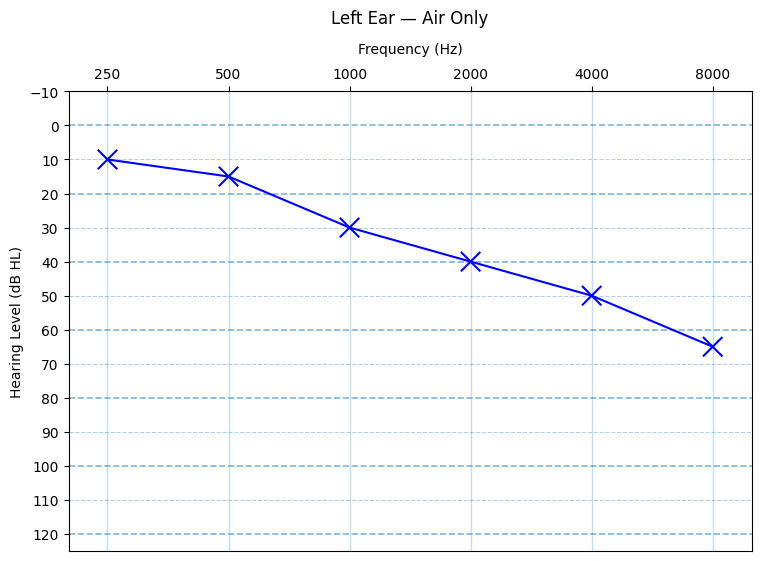

In [3]:
fig, ax = left.plot(ear='left', title='Left Ear — Air Only', show=False)
plt.show()

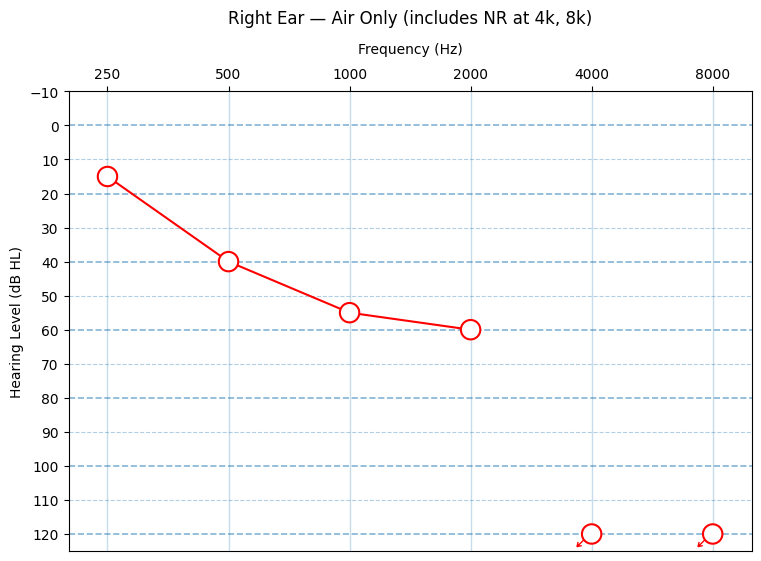

In [4]:
fig, ax = right.plot(ear='right', title='Right Ear — Air Only (includes NR at 4k, 8k)', show=False)
plt.show()

## Single Ear — Air + Bone Overlay

Verify bone conduction symbols render with `show_bone=True`.

Expected: air symbols (O/X) with bone brackets overlaid at bone frequencies.

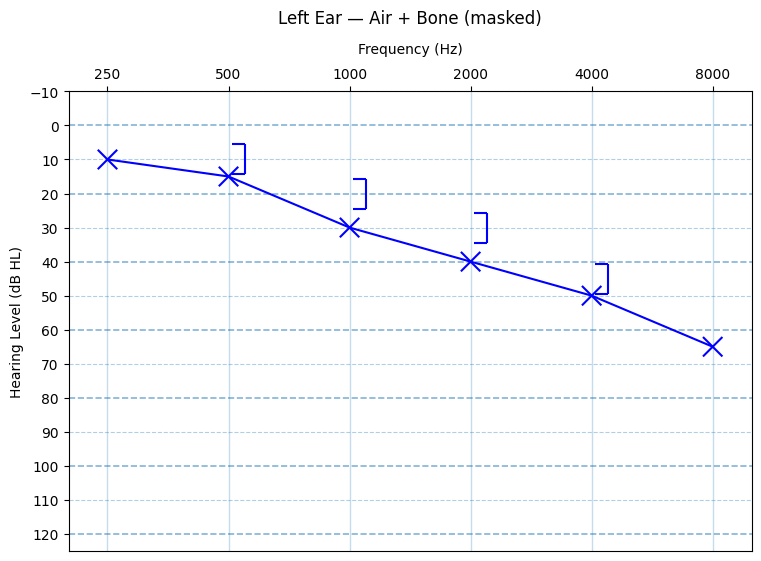

In [5]:
fig, ax = left.plot(ear='left', show_bone=True, title='Left Ear — Air + Bone (masked)', show=False)
plt.show()

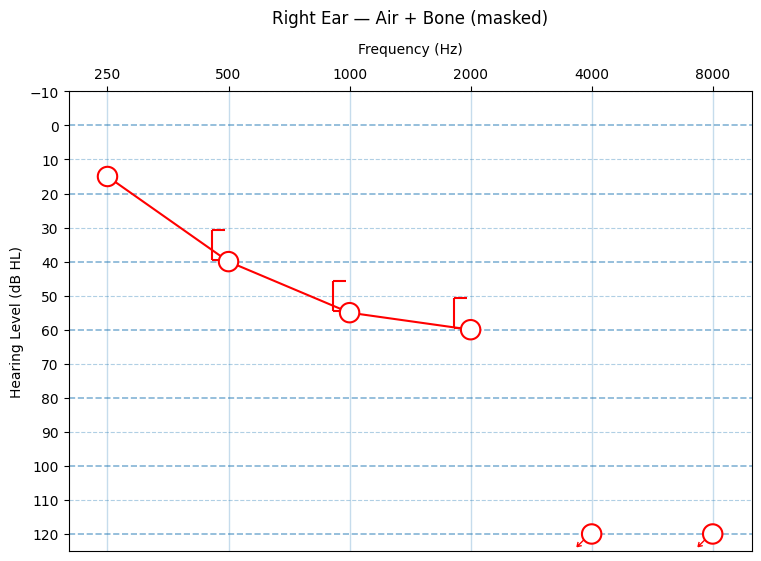

In [6]:
fig, ax = right.plot(ear='right', show_bone=True, title='Right Ear — Air + Bone (masked)', show=False)
plt.show()

## Single Ear — Soundfield in Isolation

Soundfield thresholds are plotted as green "S" text markers with connecting lines.

`show_air=False` hides air conduction to show soundfield in isolation.

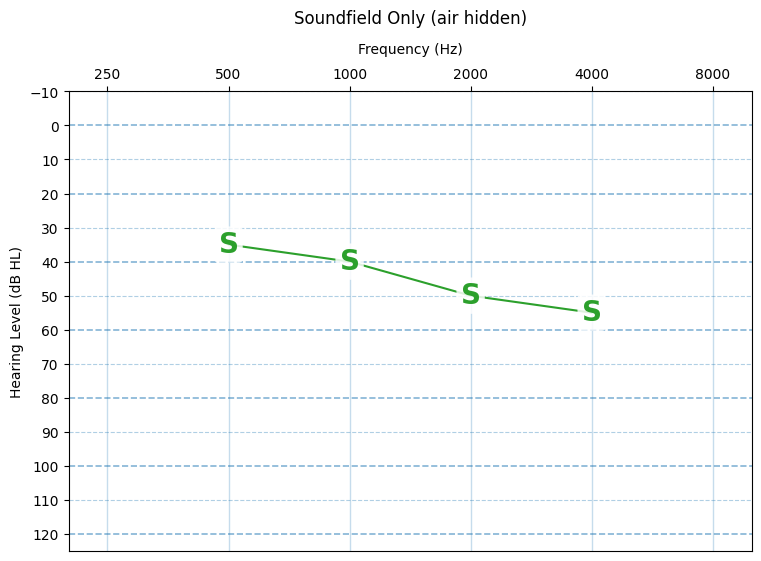

In [7]:
fig, ax = sf_ear.plot(
    ear='right',
    show_air=False,
    show_soundfield=True,
    title='Soundfield Only (air hidden)',
    show=False,
)
plt.show()

## Single Ear — CI Aided in Isolation

Cochlear implant aided thresholds are plotted as "CI" text markers in the ear's color.

`show_air=False` hides air conduction to show CI aided thresholds in isolation.

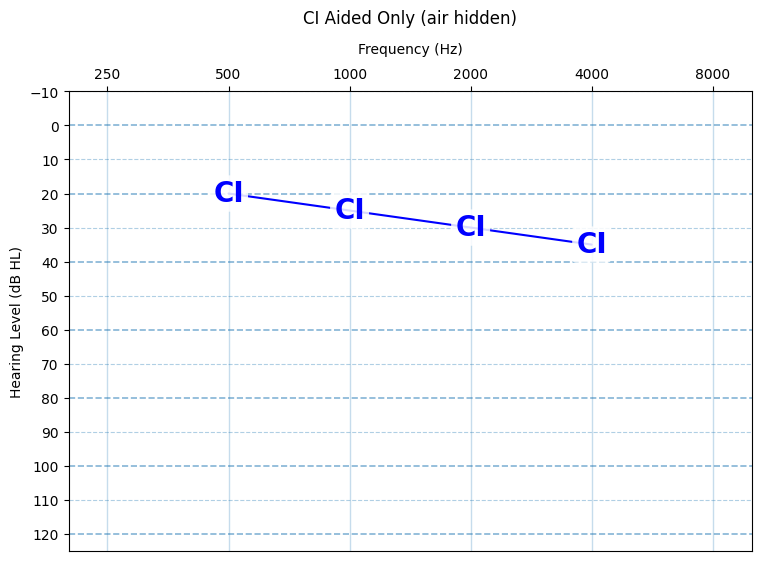

In [8]:
fig, ax = left.plot(
    ear='left',
    show_air=False,
    show_ci=True,
    title='CI Aided Only (air hidden)',
    show=False,
)
plt.show()

## Binaural — Single Panel (Combined)

Both ears on one axes. `two_panel=False`.

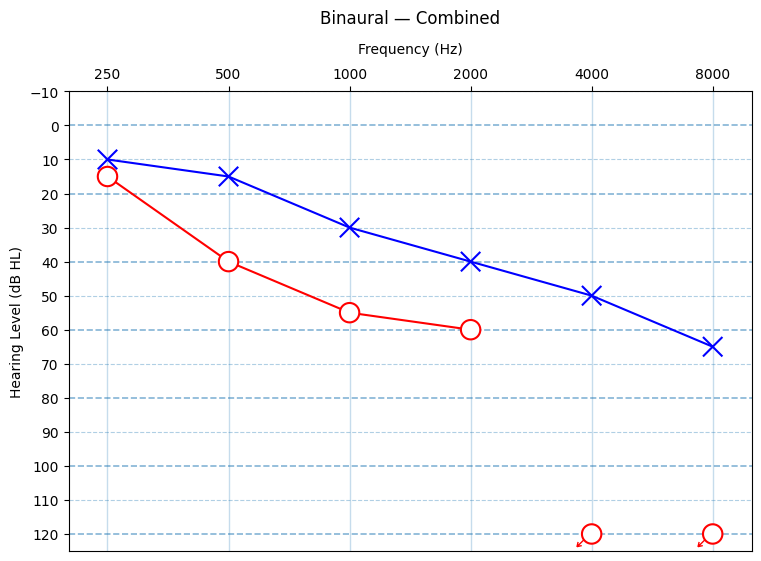

In [9]:
fig, ax = ba.plot(two_panel=False, title='Binaural — Combined', show=False)
plt.show()

## Binaural — Two Panel (Clinic Style)

Right ear on left panel, left ear on right panel. Default layout.

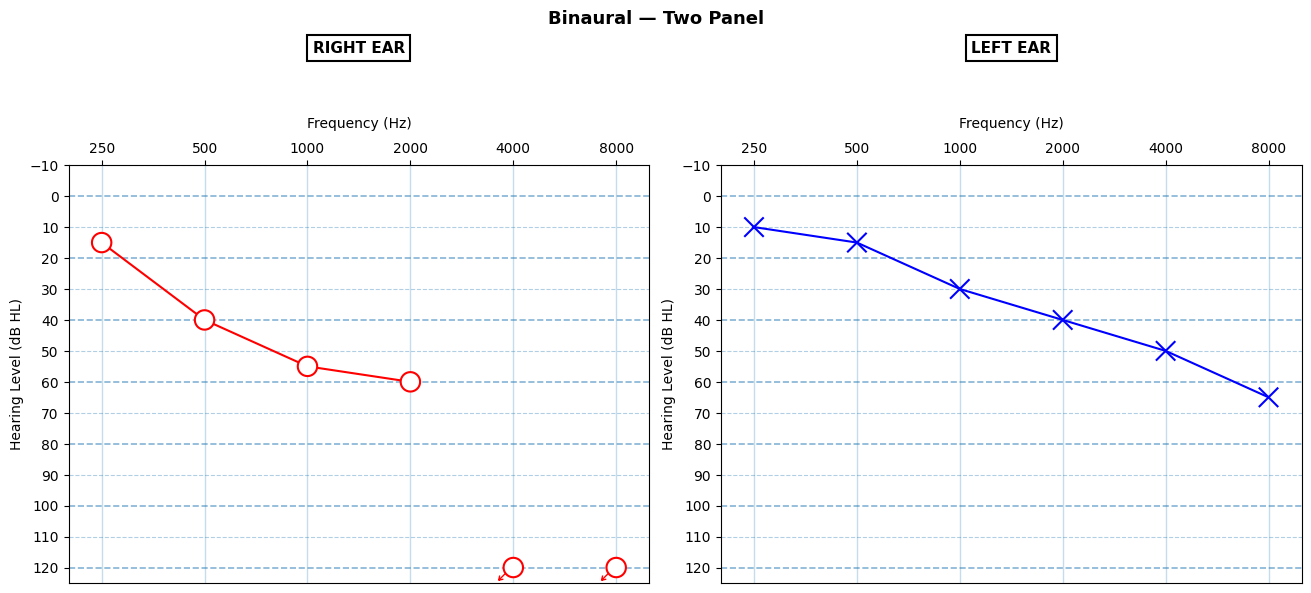

In [10]:
fig, axes = ba.plot(two_panel=True, title='Binaural — Two Panel', show=False)
plt.show()

## Binaural — Two Panel with Soundfield + CI

Soundfield is a binaural test condition — on two-panel layout it is merged and mirrored on both panels (green "S").

CI aided thresholds are ear-specific and plotted in the corresponding ear color.

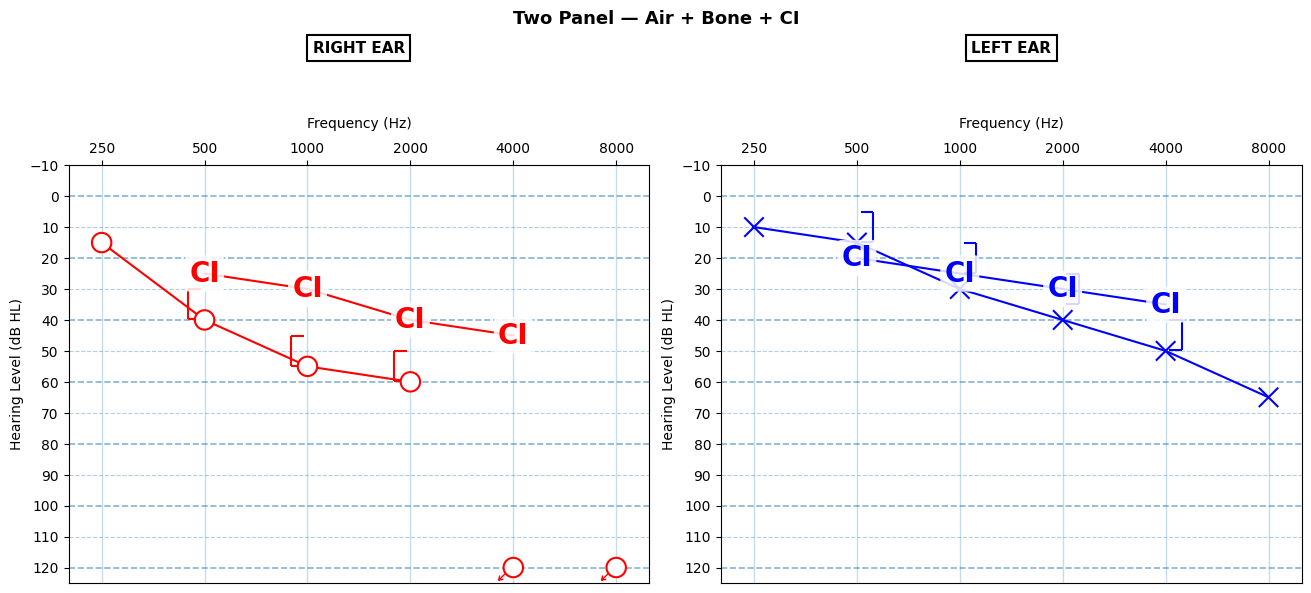

In [11]:
fig, axes = ba.plot(
    two_panel=True,
    show_bone=True,
    show_ci=True,
    title='Two Panel — Air + Bone + CI',
    show=False,
)
plt.show()

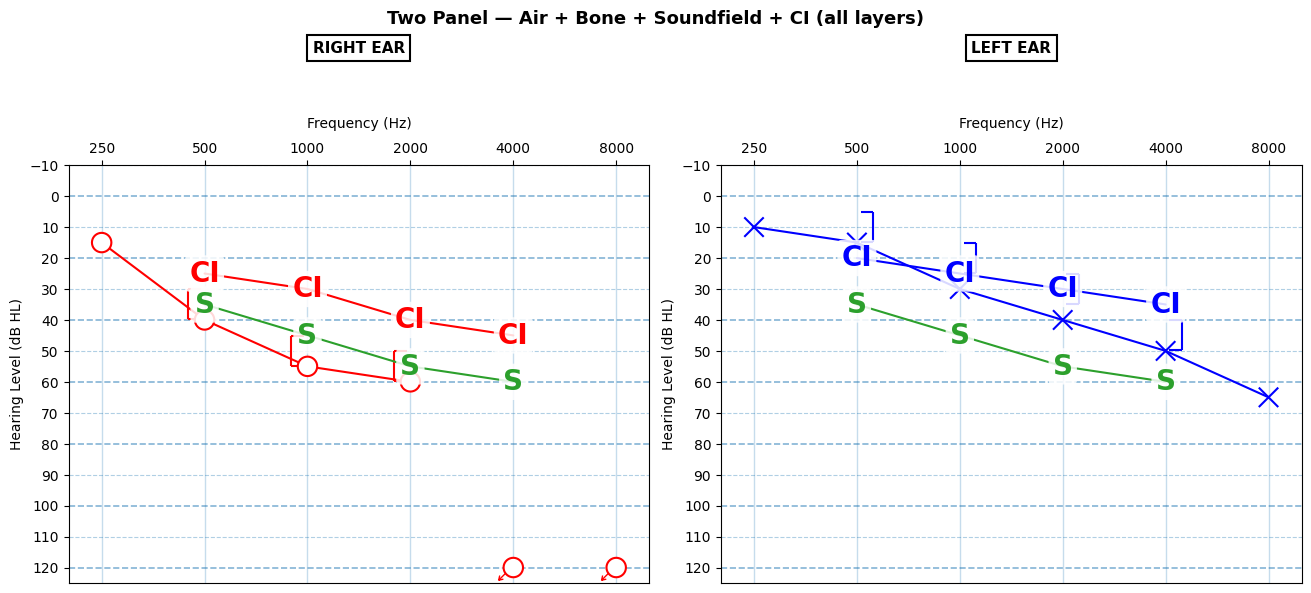

In [12]:
# Soundfield stored on the right ear — mirrored to both panels
ba_with_sf = BinauralAudiogram(
    left=left,
    right=EarAudiogram(
        air=right.air,
        bone=right.bone,
        ci=right.ci,
        soundfield={
            500:  ThresholdPoint(35.0),
            1000: ThresholdPoint(45.0),
            2000: ThresholdPoint(55.0),
            4000: ThresholdPoint(60.0),
        },
    ),
)

fig, axes = ba_with_sf.plot(
    two_panel=True,
    show_bone=True,
    show_soundfield=True,
    show_ci=True,
    title='Two Panel — Air + Bone + Soundfield + CI (all layers)',
    show=False,
)
plt.show()

## Binaural — Single Panel with Soundfield + CI

Same data on a combined single-axes plot.

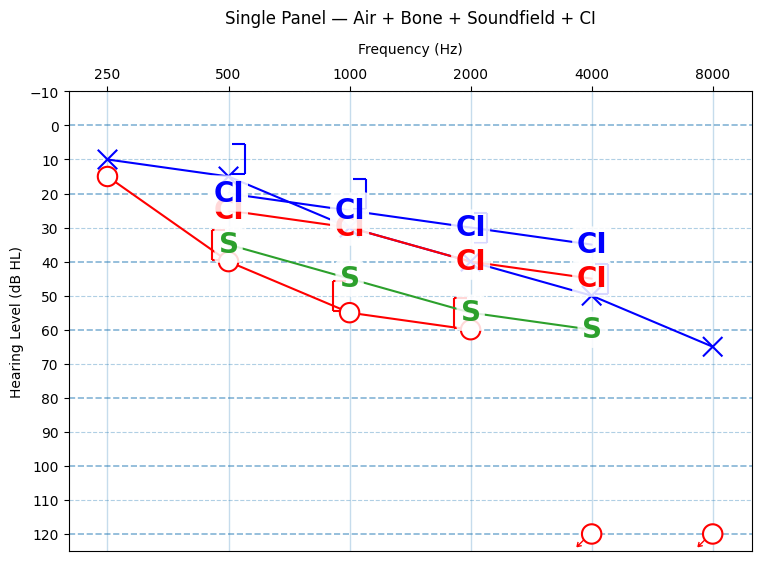

In [13]:
fig, ax = ba_with_sf.plot(
    two_panel=False,
    show_bone=True,
    show_soundfield=True,
    show_ci=True,
    title='Single Panel — Air + Bone + Soundfield + CI',
    show=False,
)
plt.show()

## Axes Presets

Compare all named presets: `ansi`, `ehf`, `mei`.

In [ ]:
from audiogram_object.plot_mpl import AXES_PRESETS, new_audiogram_canvas

canonical = ['ansi', 'ehf', 'mei']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes.flatten(), canonical):
    from audiogram_object.plot_mpl import setup_audiogram_axes
    setup_audiogram_axes(ax, preset=name, title=f'Preset: {name}')

plt.tight_layout()
plt.show()

## EHF Supplemental Plot

Extended high-frequency (8k–20k) supplemental audiogram using the `ehf` preset.

In [ ]:
left_ehf = EarAudiogram(air={
    8000: 25, 10000: 35, 11200: 40, 12500: 45, 14000: 55, 16000: 70, 18000: 80, 20000: 85,
})
right_ehf = EarAudiogram(air={
    8000: 20, 10000: 30, 11200: 35, 12500: 40, 14000: 50, 16000: 65, 18000: 75, 20000: 80,
})
ba_ehf = BinauralAudiogram(left=left_ehf, right=right_ehf)

fig, ax = ba_ehf.plot(
    two_panel=False,
    style='ehf',
    title='EHF Supplemental (8k–20k)',
    show=False,
)
plt.show()

## Plot Style Presets

Test named style presets that control axes + colors + figsize.

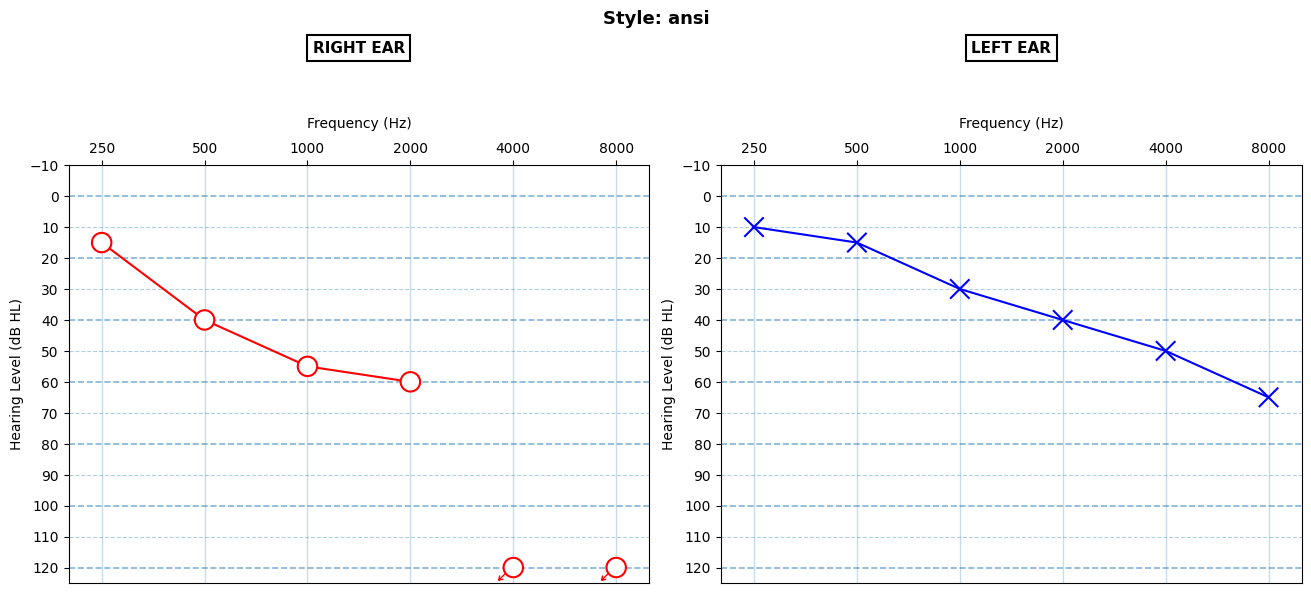

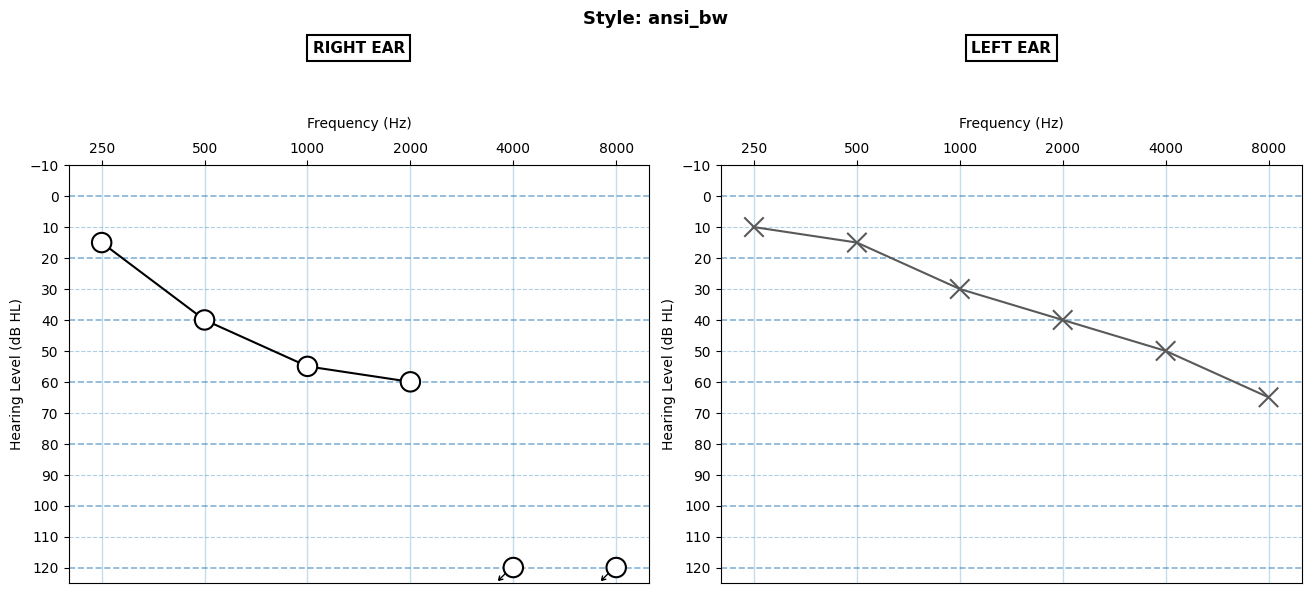

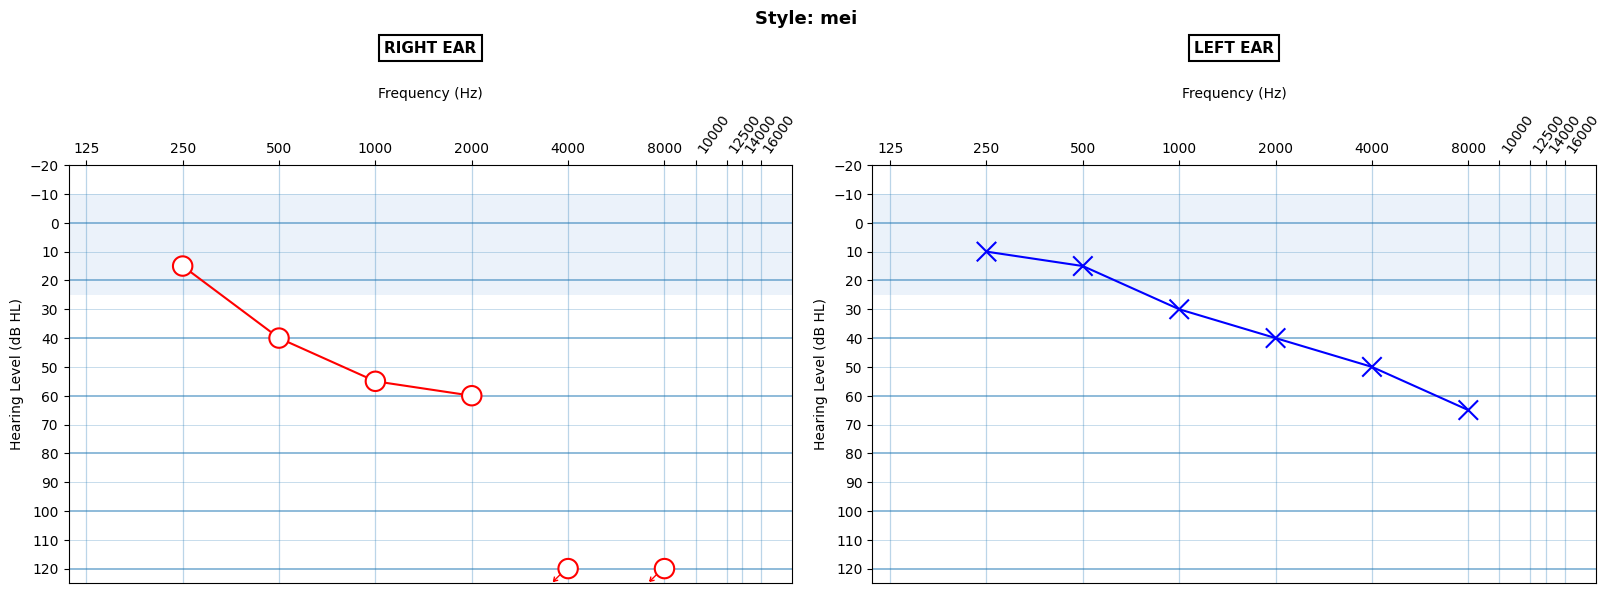

In [15]:
for style_name in ['ansi', 'ansi_bw', 'mei']:
    fig, axes = ba.plot(two_panel=True, style=style_name, title=f'Style: {style_name}', show=False)
    plt.show()

## Connecting Lines

Verify convention:
- Lines connect consecutive response-present air points (including masked)
- NR points are NOT connected

In [ ]:
# Build a case with a mix: normal, masked, NR
mixed = EarAudiogram(
    air={
        250:  ThresholdPoint(10.0),             # connected
        500:  ThresholdPoint(15.0),             # connected
        1000: ThresholdPoint(30.0, masked=True),# connected (masked included in lines)
        2000: ThresholdPoint(35.0),             # connected
        4000: ThresholdPoint(45.0),             # connected
        8000: ThresholdPoint(120.0, nr=True),   # NOT connected (NR)
    },
)

fig, ax = mixed.plot(
    ear='left',
    title='Connecting Lines: masked@1k connected, NR@8k breaks the line',
    show=False,
)
plt.show()

print('Expected: line from 250→500→1000(masked)→2000→4000, gap at 8000 (NR)')

## Edge Cases

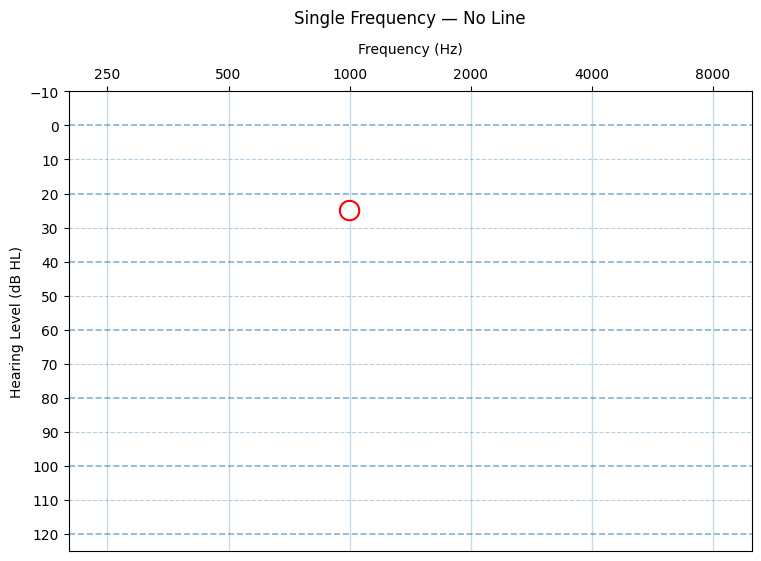

In [17]:
# Single frequency — no connecting line expected
single = EarAudiogram(air={1000: 25.0})
fig, ax = single.plot(ear='right', title='Single Frequency — No Line', show=False)
plt.show()

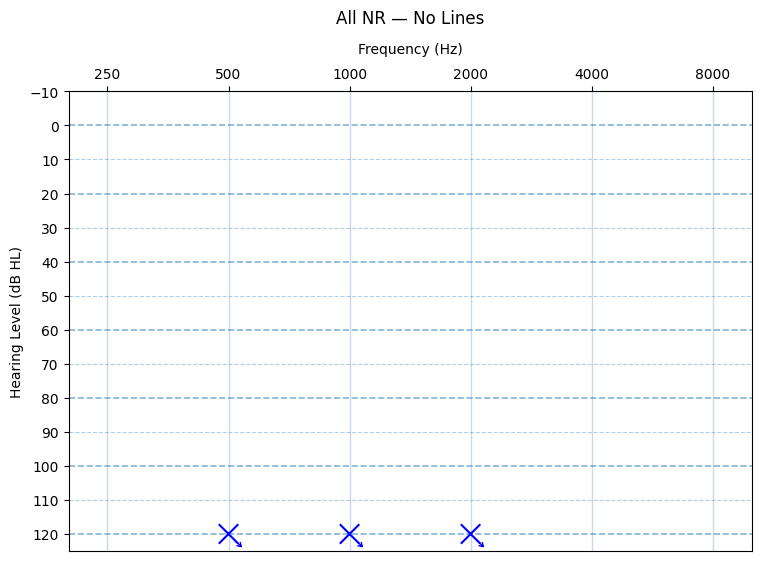

In [18]:
# All NR — no connecting lines
all_nr = EarAudiogram(air={
    500: ThresholdPoint(120.0, nr=True),
    1000: ThresholdPoint(120.0, nr=True),
    2000: ThresholdPoint(120.0, nr=True),
})
fig, ax = all_nr.plot(ear='left', title='All NR — No Lines', show=False)
plt.show()

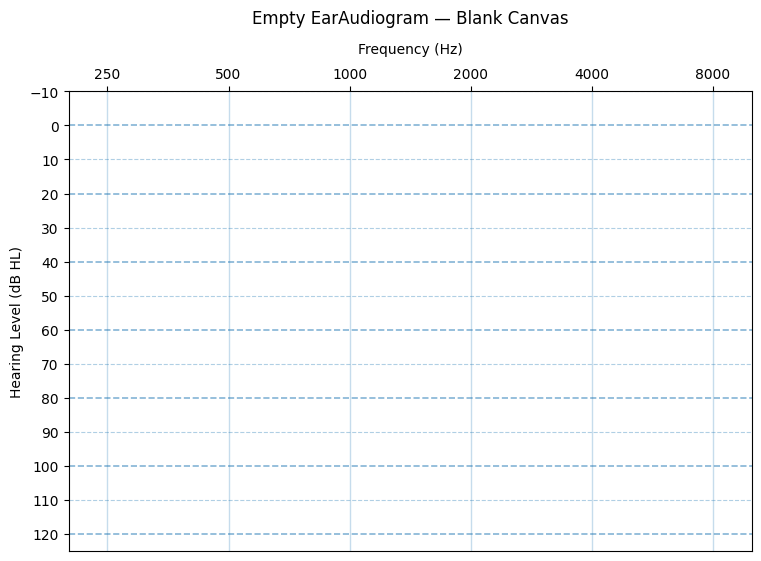

In [19]:
# Empty ear — should produce a blank canvas without error
empty = EarAudiogram()
fig, ax = empty.plot(ear='left', title='Empty EarAudiogram — Blank Canvas', show=False)
plt.show()

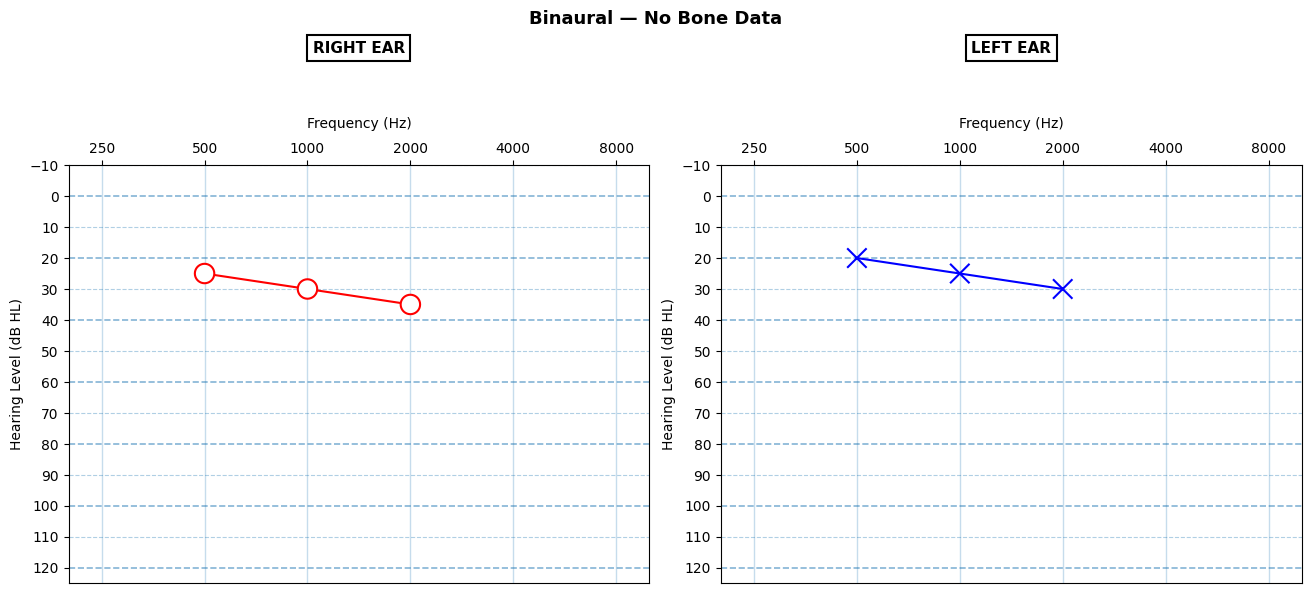

In [20]:
# Binaural with no bone — should still work
no_bone = BinauralAudiogram(
    EarAudiogram(air={500: 20.0, 1000: 25.0, 2000: 30.0}),
    EarAudiogram(air={500: 25.0, 1000: 30.0, 2000: 35.0}),
)
fig, axes = no_bone.plot(two_panel=True, title='Binaural — No Bone Data', show=False)
plt.show()

## Bone Conduction — Binaural

`BinauralAudiogram.plot(show_bone=True)` should overlay bone symbols on both panels.

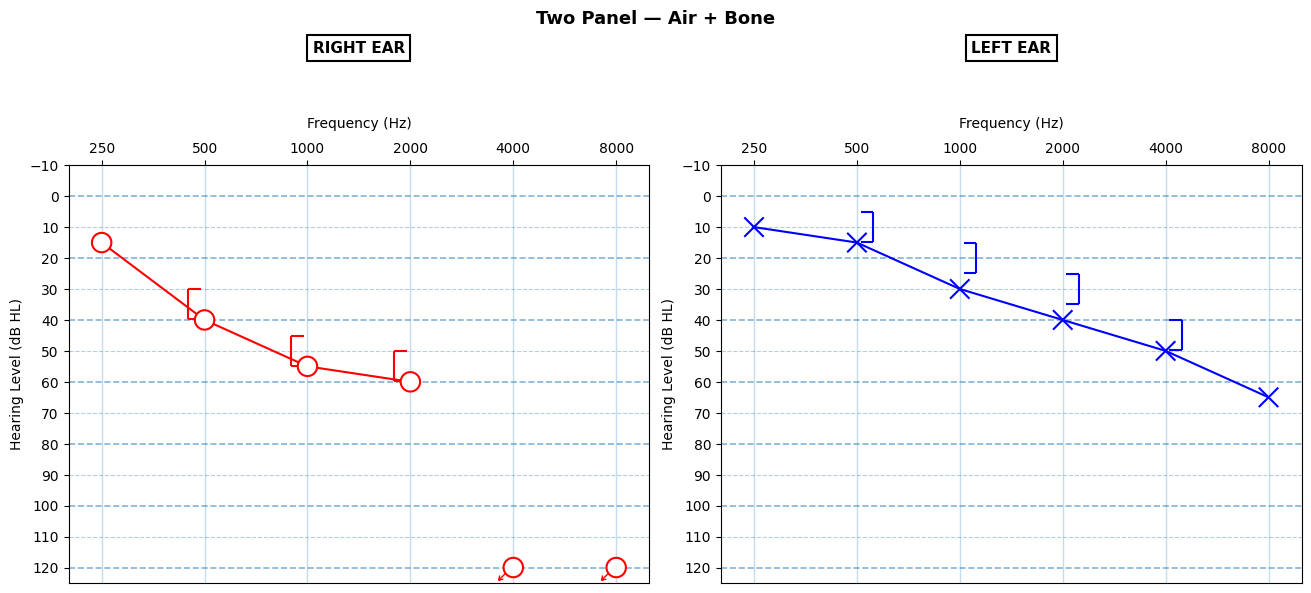

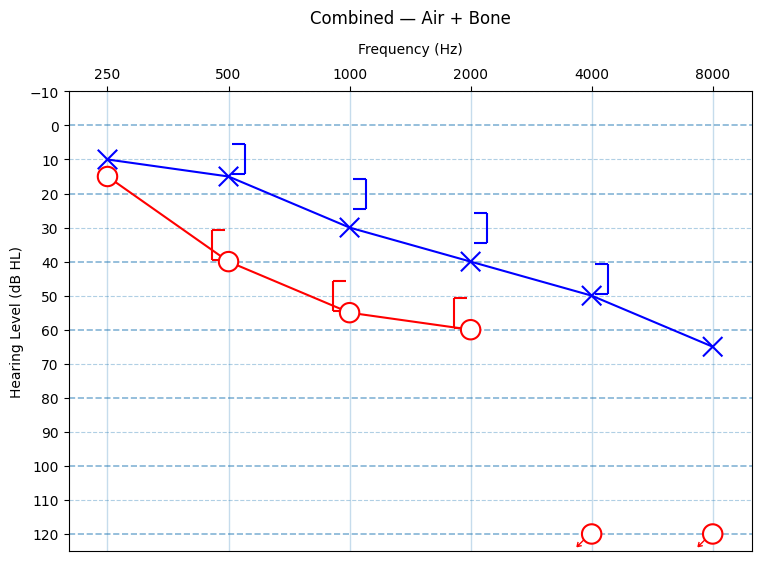

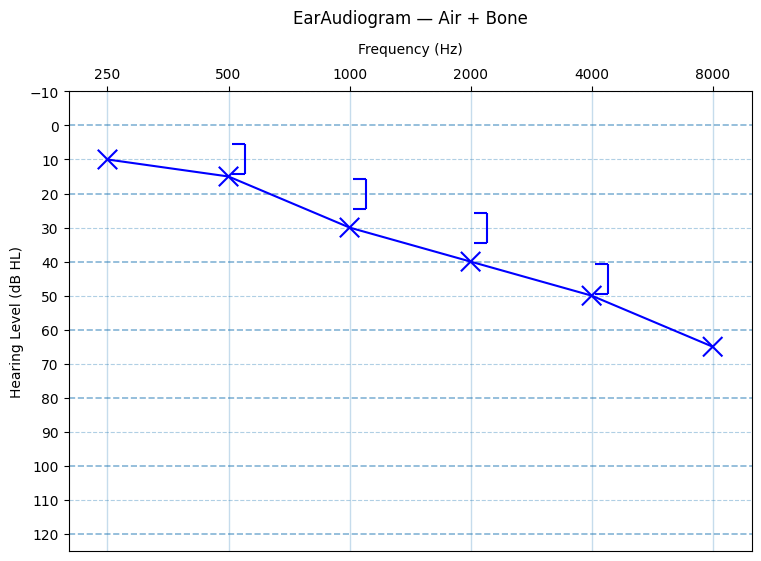

In [21]:
# Two-panel with bone
fig, axes = ba.plot(two_panel=True, show_bone=True, title='Two Panel — Air + Bone', show=False)
plt.show()

# Single panel with bone
fig, ax = ba.plot(two_panel=False, show_bone=True, title='Combined — Air + Bone', show=False)
plt.show()

# Single ear with bone (already worked, verify still does)
fig, ax = ba.left.plot(ear='left', show_bone=True, title='EarAudiogram — Air + Bone', show=False)
plt.show()

## Summary of Findings

Run all cells above and document any visual issues here after review.

In [22]:
print('Notebook complete — review plots above for visual correctness')

Notebook complete — review plots above for visual correctness
